# Planteamiento del Problema

Tenemos informacion sobre la clasificacion de medicamentos basados en la informacion general del paciente y su diagnostico. El objectivo es **predecir el resultado del tipo de medicamento** que podrian ser adecuados para cada paciente.

### Objectivo del Analisis

1. Exploracion del conjunto de datos utilizando varias tecnicas de visualizacion.
2. Construir varios modelo de ML que puedan predecir el tipo de medicamento.

### Los modelos a utilizar son:

1. Regresion Logistica
2. Maquinas de Soporte Vectorial
3. K Vecinos Mas Cercanos
4. Naive Bayes (Categorico & Gaussiano)
5. Arbol Decision
6. Bosques Aleatorios

In [ ]:
# Paquetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump, load

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importar Datos

In [ ]:
datos = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/drugs.csv')
datos.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


El set de datos no contiene valores nulos

## EDA

### Variables Categoricas

In [ ]:
datos.Drug.value_counts()

,count
Drug,
drugY,91
drugX,54
drugA,23
drugC,16
drugB,16


In [ ]:
datos.Sex.value_counts()

,count
Sex,
M,104
F,96


In [ ]:
datos.BP.value_counts()

,count
BP,
HIGH,77
LOW,64
NORMAL,59


In [ ]:
datos.Cholesterol.value_counts()

,count
Cholesterol,
HIGH,103
NORMAL,97


### Variables Numericas

In [ ]:
datos.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [ ]:
simetria_edad = datos.Age.skew(axis = 0, skipna = True)

print('Simetria de la Edad: ', simetria_edad)

Simetria de la Edad:  0.03030835703000607


In [ ]:
simetria_Na_to_K = datos.Na_to_K.skew(axis = 0, skipna = True)

print('Simetria del Nivel de Sodio y Potasio en el cuerpo: ', simetria_Na_to_K)

Simetria del Nivel de Sodio y Potasio en el cuerpo:  1.039341186028881


<Axes: xlabel='Age', ylabel='Density'>

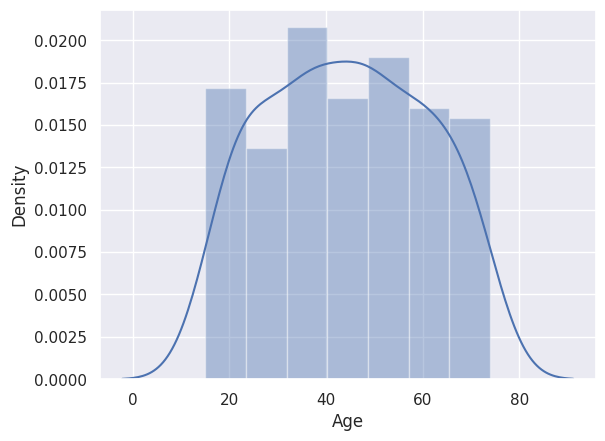

In [ ]:
import warnings
warnings.filterwarnings('ignore')
sns.distplot(datos.Age)

<Axes: xlabel='Na_to_K', ylabel='Density'>

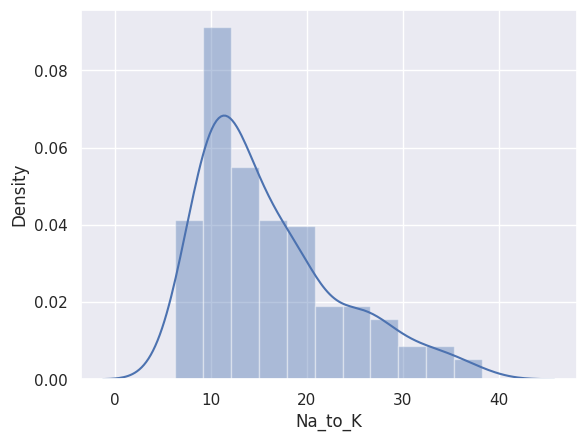

In [ ]:
sns.distplot(datos.Na_to_K)

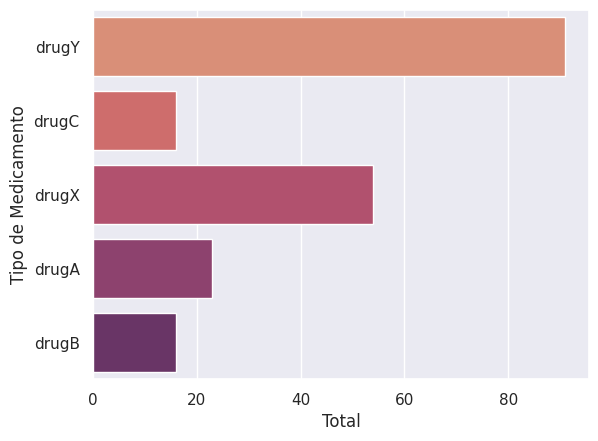

In [ ]:
sns.set_theme(style = 'darkgrid')
sns.countplot(y = 'Drug', data = datos, palette = 'flare')
plt.xlabel('Total')
plt.ylabel('Tipo de Medicamento')
plt.show()

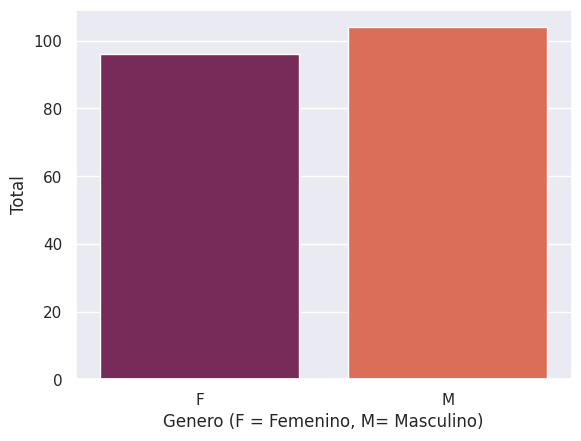

In [ ]:
sns.set_theme(style = 'darkgrid')
sns.countplot(x = 'Sex',data = datos, palette =  'rocket')
plt.xlabel('Genero (F = Femenino, M= Masculino)')
plt.ylabel('Total')
plt.show()

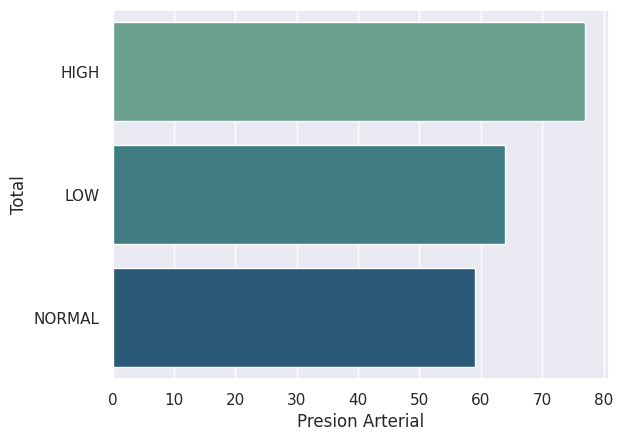

In [ ]:
sns.set_theme(style = 'darkgrid')
sns.countplot(y = 'BP',data = datos, palette =  'crest')
plt.xlabel('Presion Arterial')
plt.ylabel('Total')
plt.show()

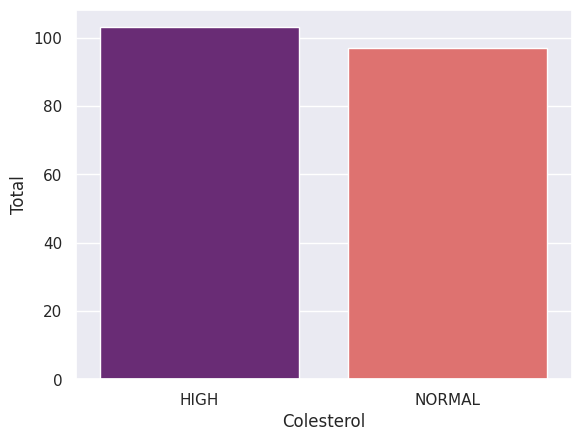

In [ ]:
sns.set_theme(style = 'darkgrid')
sns.countplot(x = 'Cholesterol',data = datos, palette =  'magma')
plt.xlabel('Colesterol')
plt.ylabel('Total')
plt.show()

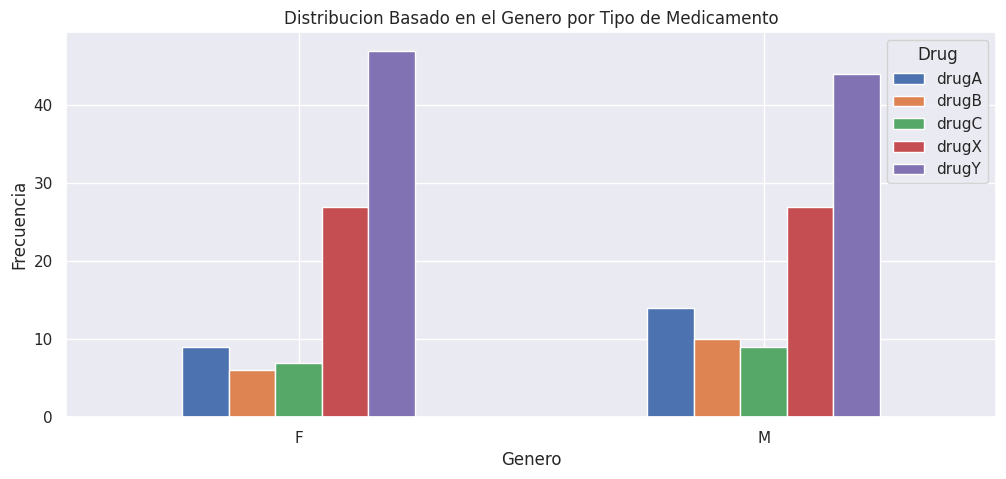

In [ ]:
# Distribucion por Medicamento y genero

pd.crosstab(datos.Sex, datos.Drug).plot(kind = 'bar', figsize = (12,5))
plt.title('Distribucion Basado en el Genero por Tipo de Medicamento')
plt.xlabel('Genero')
plt.ylabel('Frecuencia')
plt.xticks(rotation = 0)
plt.show()

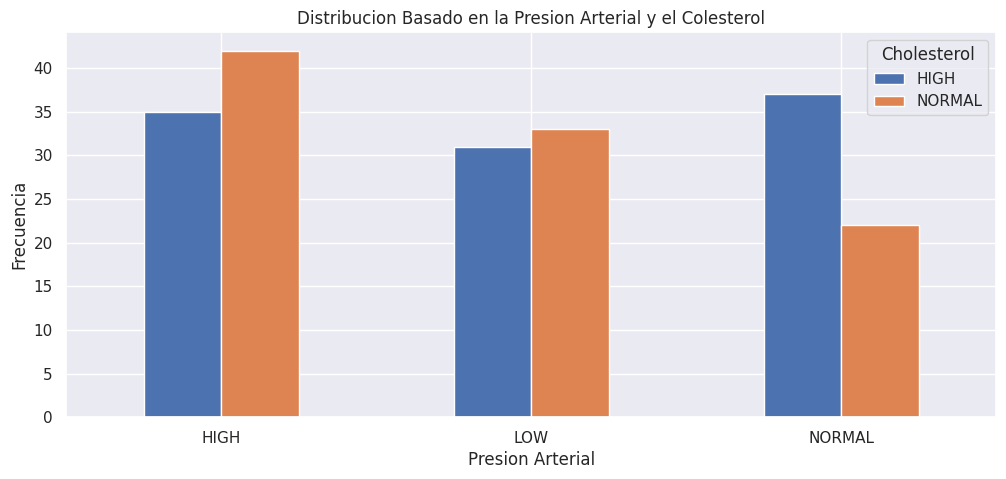

In [ ]:
# Distribucion por Colesterol y Presion Arterial

pd.crosstab(datos.BP, datos.Cholesterol).plot(kind = 'bar', figsize = (12,5))
plt.title('Distribucion Basado en la Presion Arterial y el Colesterol')
plt.xlabel('Presion Arterial')
plt.ylabel('Frecuencia')
plt.xticks(rotation = 0)
plt.show()

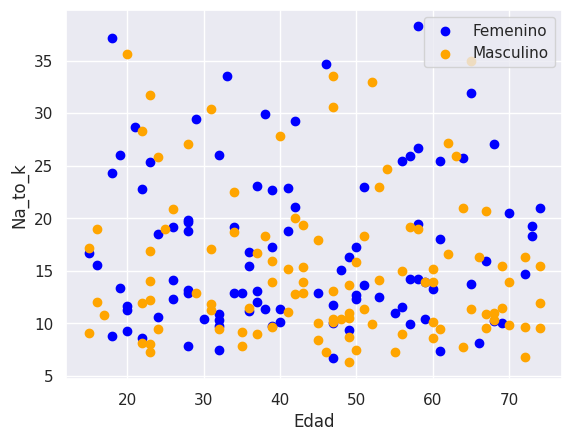

In [ ]:
plt.scatter(x = datos.Age[datos.Sex == 'F'], y = datos.Na_to_K[(datos.Sex == 'F')], c= 'Blue')
plt.scatter(x = datos.Age[datos.Sex == 'M'], y = datos.Na_to_K[(datos.Sex == 'M')], c= 'Orange')
plt.legend(['Femenino','Masculino'])
plt.xlabel('Edad')
plt.ylabel('Na_to_k')
plt.show()

## Preparacion

**EDAD**

* Por debajo 20 años
* Entre 20 a 29
* Entre 30 a 39
* Entre 40 a 49
* Entre 50 a 59
* Entre 60 a 69
* Mayor a 70

**Potasio y Sodio en la Sangre**

* Por debajo de 10
* 10 - 20
* 20 - 30
* Por encima de 30

In [ ]:
# Función para las transformaciones de binning
def binning_transformations(X):
    X = X.copy()
    bin_edad = [0,19,29,39,49,59,69,80]
    categoria_edad = ['<20s','20s','30s','40s','50s','60s','>70s']
    X['Rango_Edad'] = pd.cut(X['Age'], bins=bin_edad, labels=categoria_edad)
    X.drop(['Age'], axis=1, inplace=True)

    bin_Natok = [0,9,19,29,40]
    categorias_Natok = ['<10','10-20','20-30','>30']
    X['Grupo_Na_to_k'] = pd.cut(X['Na_to_K'], bins=bin_Natok, labels=categorias_Natok)
    X.drop(['Na_to_K'], axis=1, inplace=True)
    return X

## Feature Engineering

El metodo de FE (Feature Engineering) se utiliza para la codificacion de las variables categoricas para proporcionales a los modelos ML parametros que le permitan realizar una mejor prediccion. Al ser modelo matematicos, es una buena costumbre casi indispensable transformar la variables de texto en numericas categoricas.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE

# Definir el transformer
binning_transformer = FunctionTransformer(binning_transformations)


def create_pipeline(model):
    return imbpipeline(steps=[
        ('binning', binning_transformer),
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ('smote', SMOTE()),
        ('classifier', model)
    ])


### SMOTE: Tecnica de Sobremuestreo Sintetico, usamos la tecnica para generar nuevas muestras de la clase minoritaria.

### ADASYN:En lugar de generar nuevas muestras de manera uniforme en toda la clase minoritaria, genera mas "ejemplos"en las regiones donde la clase minoritaria esta menos densa (ayudar a enfocar el sobremuestreo en areas mas dificl de aprender)


### Oversampling: A diferencia del sobremuestreo, simplemente consiste en duplicar las observaciones de las clases minoritarias.

### Undersampling: A diferencia del sobremuestreo, este elimina las muestras de la clase mayoritaria para reducir el desbalance.

###BalancedRamdomForest: En cada árbol del bosque, se selecciona una muestra balanceada al azar (undersampling) para asegurar que cada árbol vea un número igual de muestras de ambas clases.

###NearMiss: Es la version mejorada de Undersampling ya que selecciona muestras de la clase mayoritaria basándose en su proximidad a la clase minoritaria. En lugar de eliminar aleatoriamente muestras de la clase mayoritaria, se seleccionan los ejemplos más cercanos a las muestras minoritarias para mantener el balance.

## Division de Datos

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X= datos.drop(['Drug'], axis =1)
y = datos['Drug']

X_train, X_test , y_train, y_test = train_test_split(X,y, test_size=0.3, random_state = 0)

## Modelos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import CategoricalNB, GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Definir los modelos
models = {
    'Regresión Logística': LogisticRegression(solver='liblinear', max_iter=200),
    'KNN': KNeighborsClassifier(),
    'SVC': SVC(kernel='linear', max_iter=200),
    'Naive Bayes Categórico': CategoricalNB(),
    'Naive Bayes Gaussiano': GaussianNB(),
    'Naive Bayes Bernoulli': BernoulliNB(),
    'Árbol de Decisión': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

### Regresion Logistica

## K Vecinos Mas Cercanos

Es un algoritmo basado en instancia de tipo supervisado. Puede usarse para clasificar nuevas muestras (valores discretos) o para predecir (regresion, valores continuos). Es uno modelos mas sencillos y sirve para clasificar los valores buscando los puntos de dato "mas similares (por cercania)"

Donde se suelen aplicar?

* Sistemas de Recomendacion
* Busquedas Semantica
* Deteccion Anomalias

**Beneficios y Contras**

Los **pros** es facil de entender y de implementar. Las **contras** requiere mucha mejora y recursos de procesamiento (CPU).

Como funciona?

1. Calcula la distancia entre el item a clasificar y el resto de items del dataset de entrenamiento.
2. Selecciona los "k" elementos mas cercanos (con menor distancia) segun funcion la que use.
3. Realiza una "votacion mayoritaria" entre los "k" puntos: los de una clase-etiqueta que "dominen" decidiran su clasificacion final.

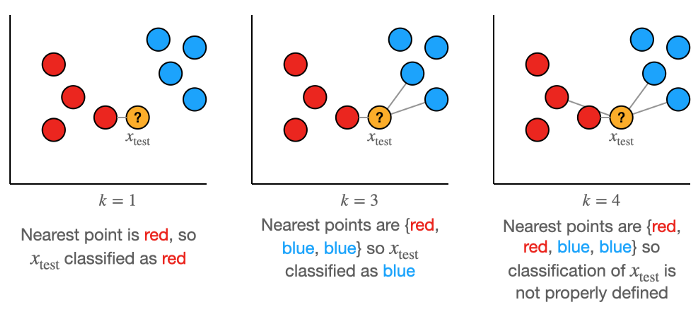

## Maquinas de Soporte Vectorial SVM

Originalmente este modelo fue desarrollado como un metodo de clasificacion binaria, sin embargo la aplicacion se ha extendido a problemas de clasificacion multiple y de regresion. Es uno de los mejores clasificadores para un amplio abanico de situacion, por lo que se considera uno de los referentes dentro del ambito de aprendizaje estadistico y machine Learning.

#### Que es una Maquina de Soporte Vectorial?

Dadas 2 o mas clases de datos etiquetados, actua como un clasificador discriminativo, definido formalmente por un hiperplano optimo que separa todas las clases. Los nuevos ejemplos que luego se mapena en ese mismo espacio se puede clasificar segun el lado de la brecha en que se encuentran.


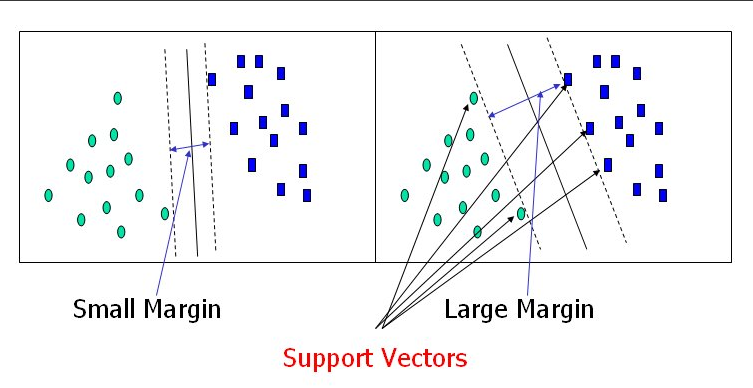

Los vectores de soporte son los puntos de datos mas cercanos al hiperplano, los puntos de un conjunto de datos que, si se eliminan, alterarian la posicion del hiperplano en division. Debido a esto, pueden considerarse los elementos criticos de un conjunto de datos, son los que no ayudana construir nuestra SVM.

#### Que es el HiperPlano en SVM?

La geometria nos dice que un hiperplano es un subespacio de una dimension menos que su espacio ambiental. Por ejemplo, un hiperplano de un espacion n-dimensional es un subconjunto plano con dimension n-1. Por su naturaliza separa el espacio en dos medios espacios.

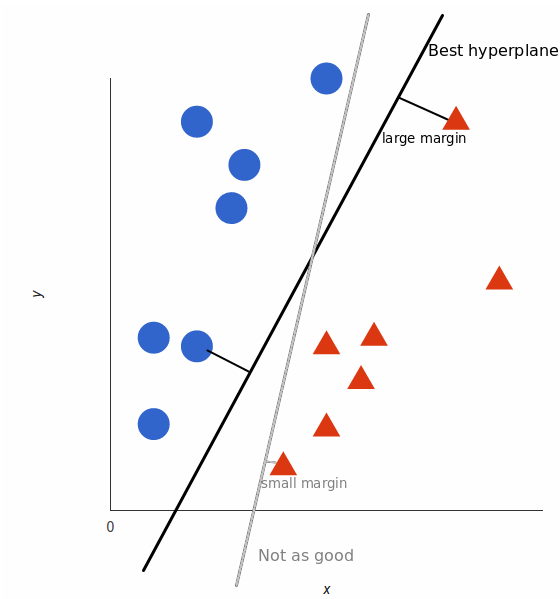

**Como funciona?**

1. Una SVM toma los puntos dados y genera el hiperplano (en 2 dimensiones, una simple linea), que separa mejor las etiquetas. Esta linea es el limite de decision.
2. Elegir el Mejor hiperplano: Para realizar esto el modelo SVM es el que maximiza los margenes de ambas etiquetas. En otras palabras: el hiperplano cuya distancia al elemento mas cercano de cada etiqueta es la mas grande.

W^T x + b = 0

## Naive Bayes

**Probabilidad Condicionada:**

P(A|B) = P (A ∩ B) / P(B)


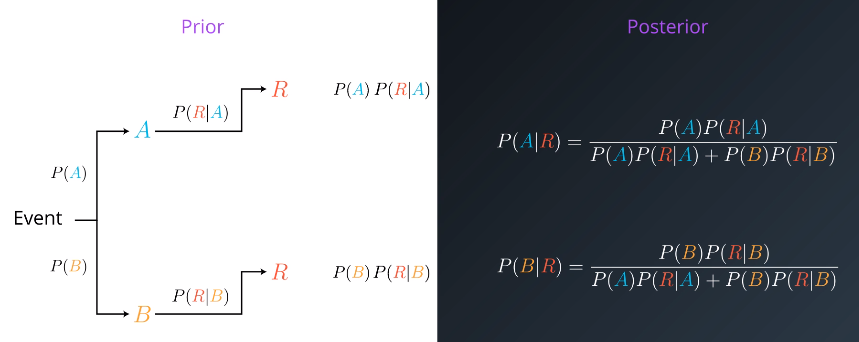

El supuesto es: vamos a considerar que los 2 trabajan en la misma oficina.

Itzel viene a la oficina 3 dias a la semana, y Sandra viene a la oficina 1 dia a la semana.

Esta es la informacion conocida.

Dada la informacion que tenemos hasta ahora y asumiento que solo trabajan 4 dias a la semana, la probabilidad de que la persona sea vista en la oficina de Itzel o Sandra es de:

* P(Itzel) = 3/4 = 0.75
* P(Sandra) = 1/4 = 0.25

Cuano vimos a la persona pasar, observamos que ellos (Itzel o Sandra) llevaban una sweater negra. Entonces tambien sabemos lo siguiente.

Itzel viste con Sweater negro 2 veces a la semana y Sandra viste con sweater negro 3 veces a la semana.

Cada semana tiene cinco dias laborales.

La probabilidad de que Itzel sea vista con Sweater negro es.
* P(Negro|Itzel) = 2/5 = 0.4

La probibilidad de que Sandra sea vista de sweater negro es.
*P(Negro|Sandra) = 3/5 = 0.6

Entonces dada esta informacion, que vimos pasar? en forma de probabilidad

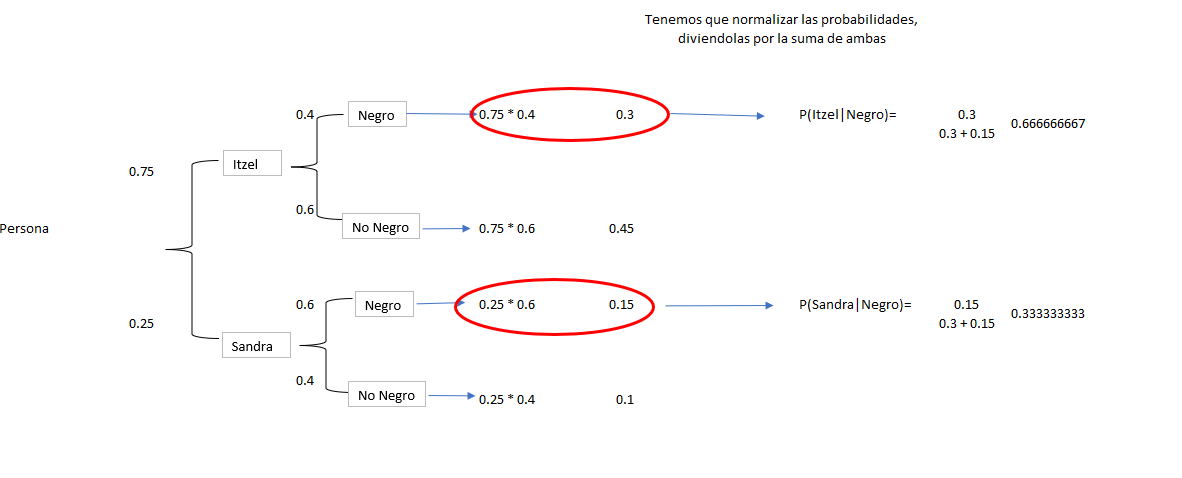

#### Teorema de Bayes

P(A|B) = P(B|A) * P(A) / P(B)

### Aplicacion Naive Bayes

1. Convertir el conjunto de datos en una tabla de frecuencias
2. Crear una tabla de probabilidad calculando las correspondiente a que ocurran los diversos eventos
3. La ecuacion de Naive Bayes se usa para calcular la probabilidad posterior de cada clase.
4. La clase con la probabilidad posterior mas alta es el resultado de la prediccion.

**Naive Bayes Categorico**

## Arbol Decision

## Random Forest

In [ ]:
# Hiperparámetros para GridSearchCV
param_grids = {
    'Naive Bayes Bernoulli': {'classifier__alpha': [0.0, 0.5, 1.0]},
    'SVC': {'classifier__C': [0.1, 1, 10]},
    'Random Forest': {'classifier__max_leaf_nodes': range(2, 50)}
}

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Diccionario para almacenar resultados
results = {}
best_acc = 0
best_model_name = ''
best_pipeline = None

# Entrenar y evaluar cada modelo
for model_name, model in models.items():
    print(f'\nEntrenando y evaluando modelo: {model_name}')
    pipeline = create_pipeline(model)

    if model_name in param_grids:
        grid = GridSearchCV(pipeline, param_grid=param_grids[model_name], cv=5, scoring='accuracy')
        grid.fit(X_train, y_train)
        best_estimator = grid.best_estimator_
        best_params = grid.best_params_
        print(f'Mejores parámetros para {model_name}: {best_params}')
    else:
        best_estimator = pipeline
        best_estimator.fit(X_train, y_train)

    y_pred = best_estimator.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(f'Precisión de {model_name}: {acc*100:.2f}%')

    results[model_name] = acc

    # Actualizar el mejor modelo si la precisión es mayor
    if acc > best_acc:
        best_acc = acc
        best_model_name = model_name
        best_pipeline = best_estimator


Entrenando y evaluando modelo: Regresión Logística
              precision    recall  f1-score   support

       drugA       0.62      1.00      0.77         5
       drugB       0.75      1.00      0.86         3
       drugC       0.67      1.00      0.80         4
       drugX       0.82      1.00      0.90        18
       drugY       1.00      0.67      0.80        30

    accuracy                           0.83        60
   macro avg       0.77      0.93      0.83        60
weighted avg       0.88      0.83      0.83        60

[[ 5  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  4  0  0]
 [ 0  0  0 18  0]
 [ 3  1  2  4 20]]
Precisión de Regresión Logística: 83.33%

Entrenando y evaluando modelo: KNN
              precision    recall  f1-score   support

       drugA       0.40      0.40      0.40         5
       drugB       0.30      1.00      0.46         3
       drugC       0.50      1.00      0.67         4
       drugX       0.75      1.00      0.86        18
       drugY       1

## Comparacion de Modelos

In [ ]:
# Mostrar comparativa de resultados
data_comparacion = pd.DataFrame({
    'Modelos': list(results.keys()),
    'Puntuación': list(results.values())
})

print('\nComparativa de modelos:')
print(data_comparacion.sort_values(by='Puntuación', ascending=False))


Comparativa de modelos:
                  Modelos  Puntuación
2                     SVC    0.850000
4   Naive Bayes Gaussiano    0.850000
0     Regresión Logística    0.833333
3  Naive Bayes Categórico    0.833333
7           Random Forest    0.833333
8       Gradient Boosting    0.816667
5   Naive Bayes Bernoulli    0.816667
6       Árbol de Decisión    0.783333
1                     KNN    0.666667


### **Guardar el mejor modelo**

In [ ]:
print(f'\nEl mejor modelo es: {best_model_name} con una precisión de {best_acc*100:.2f}%')
# Guardar el mejor modelo pickle
dump(best_pipeline, 'mejor_modelo.joblib')


El mejor modelo es: SVC con una precisión de 85.00%


['mejor_modelo.joblib']

### **Generar predicciones a nuevos datos**

In [ ]:
nuevos_datos = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/datos_nuevos_clasi_multiclase.csv')
nuevos_datos

,Age,Sex,BP,Cholesterol,Na_to_K
0,29,F,HIGH,HIGH,29.450
1,57,F,NORMAL,HIGH,14.216
2,23,M,NORMAL,HIGH,16.850
3,28,F,NORMAL,HIGH,7.798
4,31,M,HIGH,NORMAL,11.871
5,65,F,HIGH,NORMAL,31.876
6,39,F,NORMAL,NORMAL,9.709
7,59,M,HIGH,HIGH,13.935
8,67,F,NORMAL,HIGH,15.891
9,64,M,NORMAL,HIGH,7.761


In [ ]:
# Cargar el modelo guardado
loaded_model = load('mejor_modelo.joblib')

# Generar nuevas predicciones
nuevas_predicciones = loaded_model.predict(nuevos_datos)

# Crear un DataFrame con las predicciones
df_nuevas_predicciones = nuevos_datos.copy()
df_nuevas_predicciones['Predicción'] = nuevas_predicciones

In [ ]:
df_nuevas_predicciones.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Predicción
0,29,F,HIGH,HIGH,29.450,drugY
1,57,F,NORMAL,HIGH,14.216,drugX
2,23,M,NORMAL,HIGH,16.850,drugX
3,28,F,NORMAL,HIGH,7.798,drugX
4,31,M,HIGH,NORMAL,11.871,drugA
